In [1]:
# ============================================================
# Imports and Physical Constants
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import (
    G,
    k,
    m_p,
    sigma
)

# ============================================================
# Physical Constants (SI Units)
# ============================================================

AU = 1.495978707e11           # m
MSUN = 1.98847e30            # kg
RSUN = 6.957e8               # m

LSUN = 3.828e26              # W

YEAR = 365.25 * 24 * 3600    # s

MU = 2.3                     # Mean molecular weight
MH = m_p                     # Hydrogen mass

SIGMA_SB = sigma             # Stefan-Boltzmann constant

PI = np.pi                   # Pi


# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------

plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['image.cmap'] = 'inferno'

print("Physical constants loaded successfully.")

Physical constants loaded successfully.


In [2]:
# ============================================================
# Typical Disk Parameters
# (Can be modified later)
# ============================================================

# --------------------
# Stellar Parameters
# --------------------

MSTAR = 0.75                 # Stellar mass [Msun]
RSTAR = 1.0888               # Stellar radius [Rsun]
LSTAR = 0.242                # Stellar luminosity [Lsun]
TEFF = 4000.0                # Effective temperature [K]

# --------------------
# Disk Geometry
# --------------------

RIN = 4.5784                 # Inner radius [AU]
ROUT = 192.95                # Outer radius [AU]

NR = 500                     # Radial cells
NZ = 300                     # Vertical cells

# --------------------
# Surface Density
# --------------------

RC = 48.0                    # Characteristic radius [AU]
GAMMA = 1.5181               # Surface density exponent

MDISK = 0.0448               # Total gas mass [Msun]

# --------------------
# Temperature Profile
# --------------------

T0 = 150.0                   # Temperature at R0 [K]
R0 = 1.0                     # Reference radius [AU]

# flaring index 
BETA = 1.2121

# Hydrostatic-equilibrium-consistent temperature exponent
Q = 3.0 - 2.0*BETA           # ≈ 0.5758

# Alternative commonly adopted value:
# Q = 0.5

print("Disk parameters loaded.")
print(f"Temperature exponent q = {Q:.4f}")

# ============================================================
# Utility Functions
# ============================================================

def au_to_m(x):
    return x * AU


def m_to_au(x):
    return x / AU


def msun_to_kg(x):
    return x * MSUN


Disk parameters loaded.
Temperature exponent q = 0.5758


In [3]:
# ============================================================
# Surface Density Normalization
# ============================================================

from scipy.integrate import simpson

# ------------------------------------------------------------
# Convert Parameters to SI Units
# ------------------------------------------------------------

RIN_SI = au_to_m(RIN)
ROUT_SI = au_to_m(ROUT)
RC_SI = au_to_m(RC)
MDISK_SI = msun_to_kg(MDISK)

# ------------------------------------------------------------
# Self-Similar Surface Density Shape
# ------------------------------------------------------------

def sigma_shape(R):
    x = R / RC_SI
    return x**(-GAMMA) * np.exp(-(x)**(2.0 - GAMMA))

# ------------------------------------------------------------
# Compute Surface Density Normalization
# ------------------------------------------------------------

R_int = np.logspace(
            np.log10(RIN_SI),
            np.log10(ROUT_SI),
            3000
        )

integrand = sigma_shape(R_int) * R_int

I = simpson(integrand, x=R_int)

SIGMA_C = MDISK_SI / (2.0 * PI * I)

# ------------------------------------------------------------
# Final Surface Density Function
# ------------------------------------------------------------

def Sigma(R):
    return SIGMA_C * sigma_shape(R)

print("Surface density normalization complete.")
print(f"Sigma_c = {SIGMA_C:.3e} kg m⁻²")

Surface density normalization complete.
Sigma_c = 2.273e+02 kg m⁻²


In [4]:
# ------------------------------------------------------------
# Radial Grid
# ------------------------------------------------------------

R = np.logspace(
        np.log10(RIN_SI),
        np.log10(ROUT_SI),
        NR
    )

R_AU = m_to_au(R)

# ------------------------------------------------------------
# Grid Diagnostics
# ------------------------------------------------------------

print("Radial grid generated.")

print(f"Number of radial cells : {NR}")
print(f"Inner radius           : {R_AU[0]:.4f} AU")
print(f"Outer radius           : {R_AU[-1]:.4f} AU")

print(f"Smallest ΔR            : {(R_AU[1]-R_AU[0]):.5f} AU")
print(f"Largest ΔR             : {(R_AU[-1]-R_AU[-2]):.5f} AU")

Radial grid generated.
Number of radial cells : 500
Inner radius           : 4.5784 AU
Outer radius           : 192.9500 AU
Smallest ΔR            : 0.03445 AU
Largest ΔR             : 1.44117 AU


In [5]:
# ------------------------------------------------------------
# Power-law Temperature Profile
# ------------------------------------------------------------

def Temperature(R):

    T = T0 * (R / au_to_m(R0))**(-Q)

    # Temperature floor
    T = np.maximum(T, 0)

    return T

# ------------------------------------------------------------
# Compute Temperature on Grid
# ------------------------------------------------------------
T = Temperature(R)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Temperature profile generated.")

print(f"T(Rin)  = {T[0]:.2f} K")
print(f"T(Rc)   = {Temperature(RC_SI):.2f} K")
print(f"T(Rout) = {T[-1]:.2f} K")

print(f"Minimum temperature = {T.min():.2f} K")
print(f"Maximum temperature = {T.max():.2f} K")

Temperature profile generated.
T(Rin)  = 62.47 K
T(Rc)   = 16.14 K
T(Rout) = 7.25 K
Minimum temperature = 7.25 K
Maximum temperature = 62.47 K


In [6]:
# ============================================================
# Keplerian Quantities and Scale Height
# ============================================================

# ------------------------------------------------------------
# Stellar Mass in SI
# ------------------------------------------------------------

MSTAR_SI = msun_to_kg(MSTAR)

# ------------------------------------------------------------
# Keplerian Angular Velocity
# ------------------------------------------------------------

OMEGA = np.sqrt( G * MSTAR_SI / R**3 )

# ------------------------------------------------------------
# Keplerian Velocity
# ------------------------------------------------------------

VKEP = np.sqrt( G * MSTAR_SI / R)

# ------------------------------------------------------------
# Isothermal Sound Speed
# ------------------------------------------------------------

CS = np.sqrt( k * T / (MU * MH) )

# ------------------------------------------------------------
# Pressure Scale Height
# ------------------------------------------------------------

H = CS / OMEGA

H_AU = m_to_au(H)

ASPECT_RATIO = H / R

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Hydrostatic quantities computed.\n")

print(f"H(Rin)  = {H_AU[0]:.3f} AU")
print(f"H(Rc)   = {np.interp(RC, R_AU, H_AU):.3f} AU")
print(f"H(Rout) = {H_AU[-1]:.3f} AU")

print()

print(f"(H/R)(Rin)  = {ASPECT_RATIO[0]:.3f}")
print(f"(H/R)(Rout) = {ASPECT_RATIO[-1]:.3f}")

print()

print(f"Max sound speed = {CS.max()/1000:.3f} km/s")
print(f"Min sound speed = {CS.min()/1000:.3f} km/s")

print()

print(f"Max Keplerian velocity = {VKEP.max()/1000:.3f} km/s")
print(f"Min Keplerian velocity = {VKEP.min()/1000:.3f} km/s")

Hydrostatic quantities computed.

H(Rin)  = 0.180 AU
H(Rc)   = 3.103 AU
H(Rout) = 16.756 AU

(H/R)(Rin)  = 0.039
(H/R)(Rout) = 0.087

Max sound speed = 0.473 km/s
Min sound speed = 0.161 km/s

Max Keplerian velocity = 12.055 km/s
Min Keplerian velocity = 1.857 km/s


In [7]:
# ------------------------------------------------------------
# Dimensionless Vertical Coordinate
# ------------------------------------------------------------

ETA = np.linspace(
            -5.0,
             5.0,
             NZ
        )

# ------------------------------------------------------------
# Construct Physical Vertical Grid
# ------------------------------------------------------------

ZZ = H[:, None] * ETA[None, :]

ZZ_AU = m_to_au(ZZ)

# ------------------------------------------------------------
# Radial Mesh
# ------------------------------------------------------------

RR = np.repeat(
            R[:, None],
            NZ,
            axis=1
        )

RR_AU = m_to_au(RR)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Vertical grid generated.\n")

print(f"NZ = {NZ}")

print()

print(f"Maximum height at Rin  : {ZZ_AU[0,-1]:.2f} AU")
print(f"Maximum height at Rc   : {ZZ_AU[np.argmin(np.abs(R_AU-RC)),-1]:.2f} AU")
print(f"Maximum height at Rout : {ZZ_AU[-1,-1]:.2f} AU")

print()

print(f"Grid shape : {ZZ.shape}")

Vertical grid generated.

NZ = 300

Maximum height at Rin  : 0.90 AU
Maximum height at Rc   : 15.46 AU
Maximum height at Rout : 83.78 AU

Grid shape : (500, 300)


In [8]:
# ------------------------------------------------------------
# Surface Density on Radial Grid
# ------------------------------------------------------------

SIGMA = Sigma(R)

# ------------------------------------------------------------
# Expand Arrays for Broadcasting
# ------------------------------------------------------------

SIGMA_2D = SIGMA[:, None]
H_2D = H[:, None]

# ------------------------------------------------------------
# Gaussian Vertical Density Profile
# ------------------------------------------------------------

RHO = (SIGMA_2D/(np.sqrt(2.0 * PI) * H_2D)) * np.exp( -0.5 * (ZZ / H_2D)**2 )

# ------------------------------------------------------------
# Density Diagnostics
# ------------------------------------------------------------

RHO_MID = RHO[:, NZ//2]
RHO_MAX = np.max(RHO)
RHO_MIN = np.min(RHO)

# ------------------------------------------------------------
# Recover Surface Density
# ------------------------------------------------------------

SIGMA_RECOVERED = simpson(
                        RHO,
                        x=ZZ,
                        axis=1
                    )

REL_ERROR = np.mean(
                np.abs(
                    (SIGMA_RECOVERED - SIGMA)
                    /
                    SIGMA
                )
            )

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Density structure generated.\n")

print(f"Grid shape : {RHO.shape}")

print()

print(f"Maximum density : {RHO_MAX:.3e} kg m⁻³")
print(f"Minimum density : {RHO_MIN:.3e} kg m⁻³")

print()

print(f"Mean relative error in Σ recovery : {REL_ERROR:.3e}")

Density structure generated.

Grid shape : (500, 300)

Maximum density : 8.649e-08 kg m⁻³
Minimum density : 2.309e-18 kg m⁻³

Mean relative error in Σ recovery : 5.733e-07


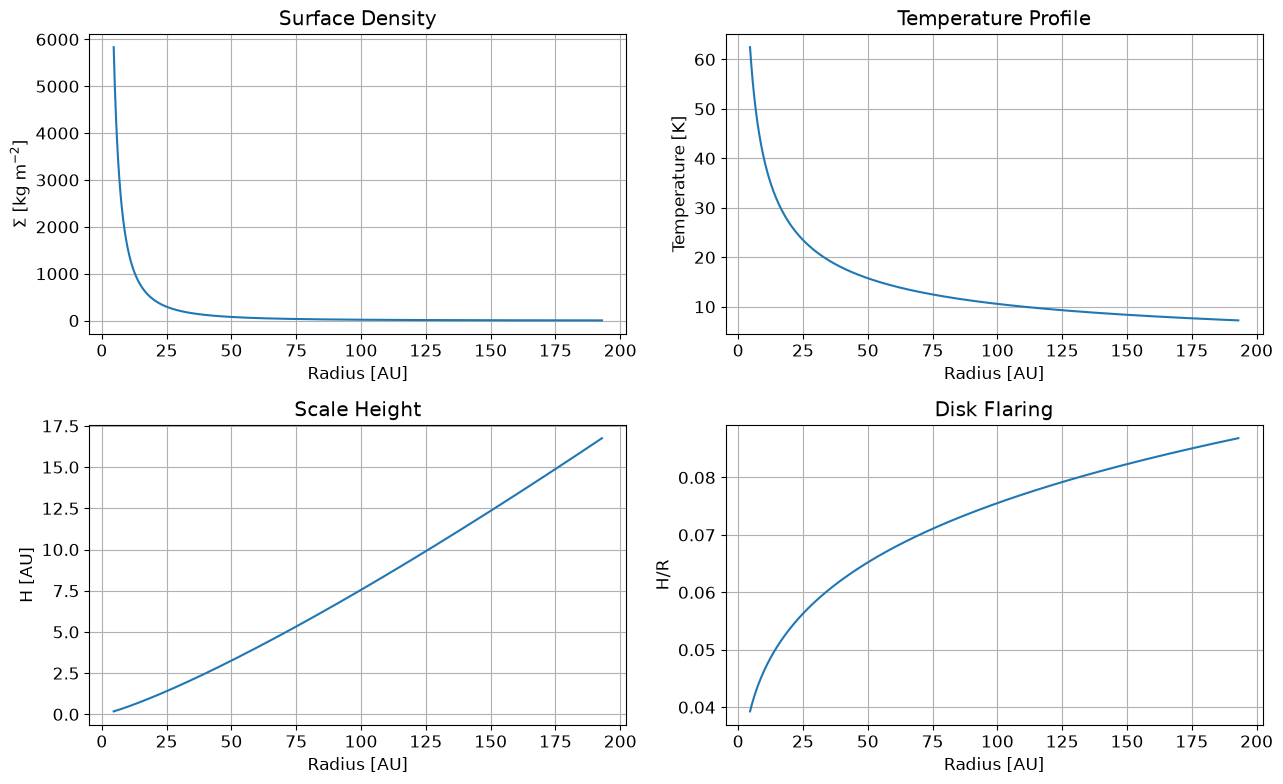

In [13]:
# ============================================================
# Diagnostics and Basic Plots (Linear X-axis)
# ============================================================

fig, ax = plt.subplots(2, 2, figsize=(13, 8))


# ------------------------------------------------------------
# Surface Density
# ------------------------------------------------------------

ax[0,0].plot(R_AU, SIGMA)

ax[0,0].set_xlabel("Radius [AU]")
ax[0,0].set_ylabel(r"$\Sigma$ [kg m$^{-2}$]")

ax[0,0].set_title("Surface Density")


# ------------------------------------------------------------
# Temperature
# ------------------------------------------------------------

ax[0,1].plot(R_AU, T)

ax[0,1].set_xlabel("Radius [AU]")
ax[0,1].set_ylabel("Temperature [K]")

ax[0,1].set_title("Temperature Profile")


# ------------------------------------------------------------
# Scale Height
# ------------------------------------------------------------

ax[1,0].plot(R_AU, H_AU)

ax[1,0].set_xlabel("Radius [AU]")
ax[1,0].set_ylabel("H [AU]")

ax[1,0].set_title("Scale Height")


# ------------------------------------------------------------
# Aspect Ratio
# ------------------------------------------------------------

ax[1,1].plot(R_AU, ASPECT_RATIO)

ax[1,1].set_xlabel("Radius [AU]")
ax[1,1].set_ylabel("H/R")

ax[1,1].set_title("Disk Flaring")


plt.tight_layout()
plt.show()